# Figure 3 — The Paradox of Exploratory Causal Inference

Reproduces Figure 3 of *Exploratory Causal Inference in SAEnce* (ICLR 2026).

The claim: as the trial gets more powerful — either more samples `n` or a bigger effect `tau` —
multiple testing flags **every** weakly entangled coordinate as significantly affected, and
Bonferroni does not save you. The threshold grows like `sqrt(2 log m)`, which scales with the
*number of tests*, not the sample size, while the t-statistic grows like `sqrt(n)`.

Only one coordinate carries a real effect here, so the correct answer is a rejection rate of
`1/m`. Watch the three curves walk away from it.

No downloads, no GPU, pure numpy. This also doubles as the unit test for the NES code that
gets reused on CelebA — the answer is known analytically, which is not true once you are
staring at 9,216 SAE codes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

M          = 100        # number of coordinates (codes)
N_SEEDS    = 10         # replications, as in the paper
ALPHA      = 0.05
LEAK       = 0.01       # entanglement strength, from the paper
rng_global = np.random.default_rng(0)

## 1. Data generating process

Straight from the paper's numerical illustration:

```
T ~ Bernoulli(0.5)
Y | T=t ~ N(tau*t, 1)                         the single true effect
Z = [Z_A, Z_B],  Z_A = Y                      principal channel
Z_B | Y=y ~ N(0.01*y*1_{m-1}, I_{m-1})        entangled (leaky) channels
```

`Z_A` is the only coordinate that genuinely encodes the outcome. Every `Z_B` is a bystander
that happens to correlate with `Y` at strength 0.01 — semantically irrelevant, but its true
effect is **not zero**. That is the whole point: these are not false positives, so no
correction can remove them.

In [2]:
def simulate(n, tau, m=M, rng=None, leak=LEAK):
    """Return (T, Z) with Z[:, 0] the principal channel and Z[:, 1:] the leaky ones."""
    rng = rng or np.random.default_rng()
    T = rng.integers(0, 2, size=n)
    Y = rng.normal(tau * T, 1.0)
    Z = np.empty((n, m), dtype=np.float32)
    Z[:, 0] = Y
    step = 25                                   # chunked so n=1e6 stays inside memory
    for s in range(1, m, step):
        e = min(s + step, m)
        Z[:, s:e] = rng.normal(leak * Y[:, None], 1.0, size=(n, e - s))
    return T, Z

## 2. The test

One function covers everything. With `S = []` it is a plain Welch two-sample t-test on every
coordinate — that is what the three baselines use. With `S` non-empty it stratifies on the
already-discovered coordinates and aggregates, which is what NES needs (Algorithm 2).

Three details taken from the authors' supplementary code rather than the appendix pseudocode:

- cutpoints are computed **pooled over T** — splitting within arm would let the strata encode
  the treatment
- multiple rounds stratify **jointly** on everything in `S`, so the cell count multiplies
- strata missing an arm are dropped and the weights are renormalised over what is left

`n_bins=2` reproduces the shipped `> threshold` rule. Section 6 shows why that is the wrong
default here.

In [3]:
def stratified_test(T, Z, S=(), n_bins=2, threshold=0.0):
    """Weighted stratified treated-vs-control contrast for every column of Z.

    S        : columns already discovered, used to build the strata
    n_bins   : 2 reproduces the shipped `> threshold` split; higher uses pooled quantiles
    """
    n, m = Z.shape
    S = list(S)

    if not S:
        gid = np.zeros(n, dtype=np.int64)
    elif n_bins == 2:
        Sbin = (Z[:, S] > threshold).astype(np.int64)
        gid = Sbin @ (1 << np.arange(len(S), dtype=np.int64))
    else:
        gid = np.zeros(n, dtype=np.int64)
        for s in S:
            cuts = np.quantile(Z[:, s], np.linspace(0, 1, n_bins + 1)[1:-1])  # pooled, ignores T
            gid = gid * n_bins + np.searchsorted(cuts, Z[:, s])

    cells = []
    for g in np.unique(gid):
        gm = gid == g
        i1, i0 = gm & (T == 1), gm & (T == 0)
        n1, n0 = int(i1.sum()), int(i0.sum())
        if n1 < 2 or n0 < 2:            # need both arms, and ddof=1 needs 2 units
            continue
        cells.append((n1 + n0, n1, n0,
                      Z[i1].mean(0).astype(np.float64), Z[i0].mean(0).astype(np.float64),
                      Z[i1].var(0, ddof=1).astype(np.float64),
                      Z[i0].var(0, ddof=1).astype(np.float64)))

    if not cells:
        nan = np.full(m, np.nan)
        return nan, nan

    w = np.array([c[0] for c in cells], dtype=np.float64)
    w /= w.sum()

    ate = np.zeros(m); se2 = np.zeros(m); satt = np.zeros(m)
    for k, (_, n1, n0, mu1, mu0, v1, v0) in enumerate(cells):
        ate += w[k] * (mu1 - mu0)
        a, b = w[k] ** 2 * (v1 / n1), w[k] ** 2 * (v0 / n0)
        se2 += a + b
        satt += a ** 2 / max(n1 - 1, 1) + b ** 2 / max(n0 - 1, 1)   # Satterthwaite

    with np.errstate(divide="ignore", invalid="ignore"):
        tstat = ate / np.sqrt(se2)
        df = np.clip(se2 ** 2 / satt, 1.0, 1e9)
    return ate, 2.0 * student_t.sf(np.abs(tstat), df=df)

## 3. The four procedures

`t-test`, `Bonferroni` and `FDR` are the three curves in the paper's figure. NES is not in the
published Figure 3 — it is added here because this is the cheapest place to check the
implementation.

Selection inside NES is two criteria applied **in order**: keep whatever clears `alpha/m`, then
take the largest `|tau_hat|` among the survivors. Stop when nothing clears.

In [4]:
def bh_reject(p, alpha=ALPHA):
    """Benjamini-Hochberg step-up."""
    m = len(p)
    order = np.argsort(p)
    passed = p[order] <= alpha * np.arange(1, m + 1) / m
    rej = np.zeros(m, dtype=bool)
    if passed.any():
        rej[order[: np.max(np.where(passed)[0]) + 1]] = True
    return rej


def nes(T, Z, alpha=ALPHA, n_bins=2, max_cells=4096, max_steps=25):
    """Neural Effect Search. Returns the list of selected column indices."""
    n, m = Z.shape
    S = []
    for _ in range(max_steps):
        if n_bins ** (len(S) + 1) > max_cells:      # guard: cells multiply every round
            break
        ate, p = stratified_test(T, Z, S, n_bins=n_bins)
        ok = np.isfinite(p) & (p < alpha / m)
        cand = np.array([j for j in np.where(ok)[0] if j not in S], dtype=int)
        if cand.size == 0:
            break
        S.append(int(cand[np.argmax(np.abs(ate[cand]))]))
    return S

## 4. Sanity check

One draw. The naive tests should already be over-firing while NES still returns `[0]`.

In [12]:
Z

array([[ 2.5240293 ,  0.6292396 , -1.3449303 , ...,  0.2977051 ,
         1.2089407 ,  1.140877  ],
       [ 0.2189449 , -1.3674802 , -0.01214474, ...,  0.07737577,
         1.7542615 , -0.6075106 ],
       [ 2.5142355 ,  0.55950046, -1.9527388 , ..., -0.8172629 ,
        -0.52893496,  2.5339084 ],
       ...,
       [ 2.2908683 , -0.12877299,  0.23096532, ...,  2.034619  ,
        -0.07678125, -0.05054406],
       [-0.82689214,  0.7096553 , -1.2317001 , ..., -0.87116134,
         0.48164117,  0.5750146 ],
       [-0.8009908 ,  1.185575  , -0.57229424, ..., -1.905601  ,
        -1.2066959 ,  0.29148966]], shape=(1000000, 100), dtype=float32)

In [5]:
T, Z = simulate(n=20_000, tau=2.0, rng=np.random.default_rng(0))
_, p = stratified_test(T, Z)

print(f"true effects            : 1 of {M}  (column 0)")
print(f"t-test rejects          : {(p < ALPHA).sum()}")
print(f"FDR rejects             : {bh_reject(p).sum()}")
print(f"Bonferroni rejects      : {(p < ALPHA / M).sum()}")
print(f"NES returns             : {nes(T, Z, n_bins=10)}")

true effects            : 1 of 100  (column 0)
t-test rejects          : 29
FDR rejects             : 14
Bonferroni rejects      : 6
NES returns             : [0]


## 5. The two sweeps

Left panel varies `n` at fixed `tau`; right panel varies `tau` at fixed `n`. Ten seeds each,
as in the paper. Rejection rate is the fraction of the `M` coordinates flagged, so the correct
answer is the flat line at `1/M`.

`n = 1e6` with `M = 100` allocates about 400 MB, so this runs comfortably in 16 GB. Drop the
last grid point if you want it faster.

In [6]:
def rejection_rates(n, tau, seed, alpha=ALPHA):
    T, Z = simulate(n, tau, rng=np.random.default_rng(seed))
    _, p = stratified_test(T, Z)
    return {
        "t-test":     (p < alpha).sum() / M,
        "FDR":        bh_reject(p, alpha).sum() / M,
        "Bonferroni": (p < alpha / M).sum() / M,
    }


def sweep(grid, fixed, axis):
    """axis='n' sweeps sample size at fixed tau; axis='tau' sweeps effect size at fixed n."""
    out = {k: [] for k in ("t-test", "FDR", "Bonferroni")}
    err = {k: [] for k in out}
    for v in grid:
        n, tau = (int(v), fixed) if axis == "n" else (fixed, float(v))
        reps = [rejection_rates(n, tau, seed) for seed in range(N_SEEDS)]
        for k in out:
            vals = [r[k] for r in reps]
            out[k].append(np.mean(vals))
            err[k].append(np.std(vals))
    return out, err


N_GRID   = np.logspace(2, 6, 9)
TAU_GRID = np.linspace(0, 10, 11)
TAU_FIXED, N_FIXED = 2.0, 10_000

res_n,   err_n   = sweep(N_GRID,   TAU_FIXED, axis="n")
res_tau, err_tau = sweep(TAU_GRID, N_FIXED,   axis="tau")
print("done")

done


## 6. Figure 3

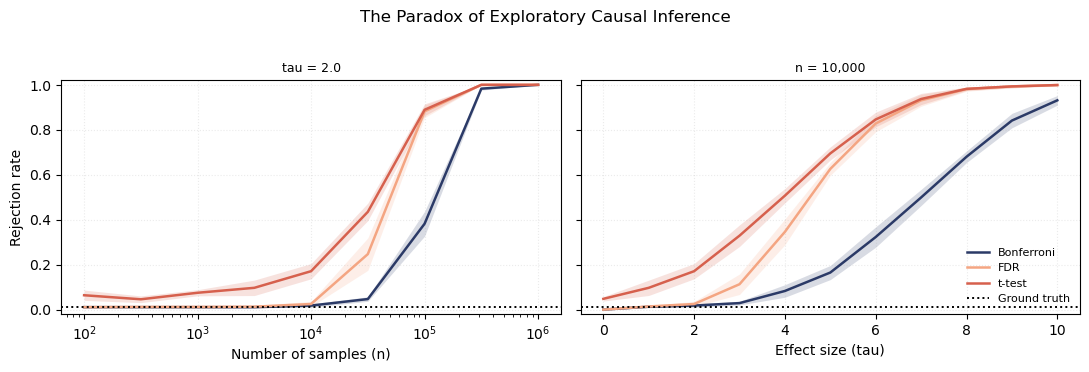

In [7]:
COLORS = {"Bonferroni": "#2b3a67", "FDR": "#f4a582", "t-test": "#d6604d"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

for ax, grid, res, err, xlabel, logx in [
    (axes[0], N_GRID,   res_n,   err_n,   "Number of samples (n)", True),
    (axes[1], TAU_GRID, res_tau, err_tau, "Effect size (tau)",     False),
]:
    for k in ("Bonferroni", "FDR", "t-test"):
        m_, s_ = np.array(res[k]), np.array(err[k])
        ax.plot(grid, m_, label=k, color=COLORS[k], lw=1.8)
        ax.fill_between(grid, m_ - s_, m_ + s_, color=COLORS[k], alpha=0.18, lw=0)
    ax.axhline(1 / M, ls=":", color="black", lw=1.4, label="Ground truth")
    if logx:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25, ls=":")

axes[0].set_ylabel("Rejection rate")
axes[0].set_title(f"tau = {TAU_FIXED}", fontsize=9)
axes[1].set_title(f"n = {N_FIXED:,}", fontsize=9)
axes[1].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("The Paradox of Exploratory Causal Inference", y=1.02)
fig.tight_layout()
plt.show()